### Import Library

In [493]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Understanding

In [494]:
df = pd.read_csv("/Users/bethe/Documents/DS Project/Healthcare Fraud/healthcare_fraud_detection.csv")
df.head()

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0


In [495]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [496]:
df.isnull().sum()/df.shape[0]*100

Provider_ID                              0.0
Claim_ID                                 0.0
Patient_Age                              0.0
Patient_Gender                           0.0
Diagnosis_Code                           0.0
Procedure_Code                           0.0
Claim_Amount                             0.0
Approved_Amount                          0.0
Insurance_Type                           3.5
Claim_Submission_Date                    0.0
Days_Between_Service_and_Claim           0.0
Number_of_Claims_Per_Provider_Monthly    0.0
Provider_Specialty                       3.5
Patient_State                            0.0
Claim_Status                             0.0
Is_Fraud                                 0.0
Length_of_Stay                           0.0
Visit_Type                               0.0
Chronic_Condition_Flag                   0.0
Prior_Visits_12m                         3.5
dtype: float64

In [497]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [498]:
# Hilangkan kolom yang tidak digunakan

df.drop(['Claim_ID', 'Diagnosis_Code', 'Patient_State', 'Procedure_Code'], axis=1, inplace=True)

In [499]:
df.head()

,Provider_ID,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,37,Male,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,Approved,0,0,Outpatient,1,2.0
1,P0121,21,Female,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,Pending,0,5,Inpatient,1,2.0
2,P0140,78,Female,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,Pending,0,5,Inpatient,1,3.0
3,P0202,65,Male,235.15,189.11,Private,2023-10-11,22,70,General Practice,Approved,0,0,Emergency,0,5.0
4,P0135,36,Male,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,Approved,0,5,Inpatient,0,4.0


In [500]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'], format='%Y-%m-%d')
df['Claim_Submission_mth'] = df['Claim_Submission_Date'].dt.month
df['Claim_Submission_yr'] = df['Claim_Submission_Date'].dt.year
df['Claim_DayOfWeek'] = df['Claim_Submission_Date'].dt.dayofweek
df['Is_Weekend'] = df['Claim_DayOfWeek'].isin([5, 6]).astype(int)

df['Claim_Amount'] = df['Claim_Amount']*17.808
df['Approved_Amount'] = df['Approved_Amount']*17.808
df['Claim_Approval_Ratio'] = df['Approved_Amount'] / (df['Claim_Amount'] + 1)
df['Claim_Amount_Diff'] = df['Claim_Amount'] - df['Approved_Amount']

### **Exploratory Data Analysis (EDA)**

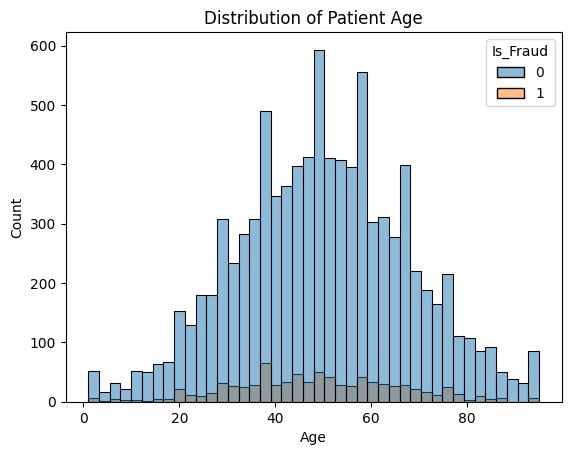

In [501]:
sns.histplot(data=df, x='Patient_Age', hue='Is_Fraud')

plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

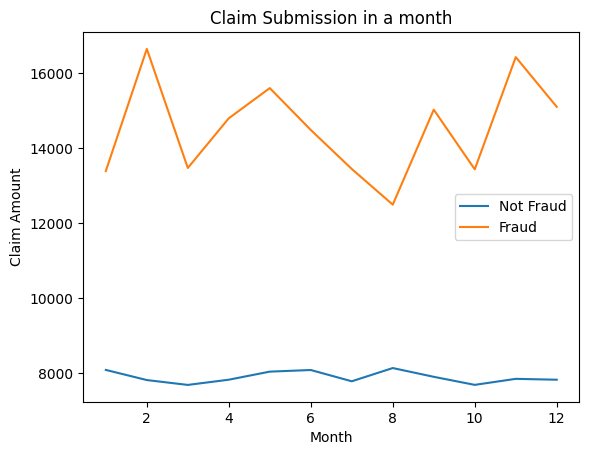

In [502]:
df_fr0 = df[df['Is_Fraud'] == 0].groupby(['Claim_Submission_mth'], as_index=False)['Claim_Amount'].median()
df_fr1 = df[df['Is_Fraud'] == 1].groupby(['Claim_Submission_mth'], as_index=False)['Claim_Amount'].median()

sns.lineplot(df_fr0, x='Claim_Submission_mth', y='Claim_Amount', label='Not Fraud')
sns.lineplot(df_fr1, x='Claim_Submission_mth', y='Claim_Amount', label='Fraud')

plt.title("Claim Submission in a month")
plt.xlabel("Month")
plt.ylabel("Claim Amount")
plt.legend()
plt.show()

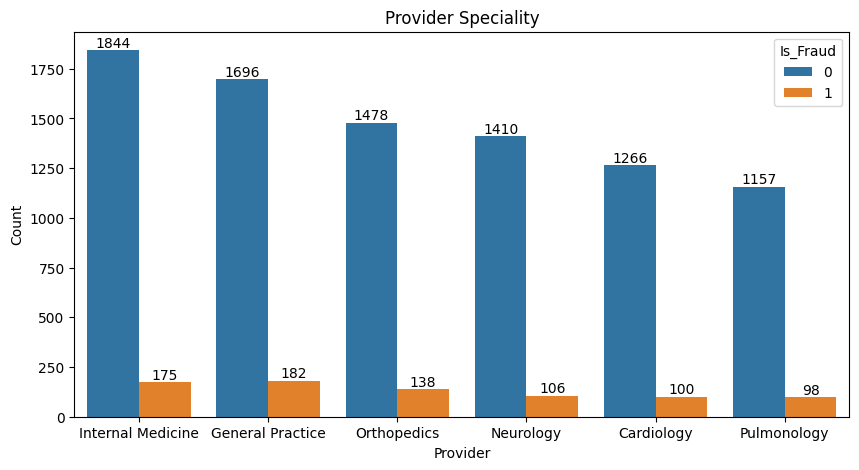

In [503]:
plt.figure(figsize=(10,5))

ax = sns.countplot(df, x=df['Provider_Specialty'], order=df['Provider_Specialty'].value_counts(ascending=False).index, hue='Is_Fraud')

for cnt in ax.containers:
    ax.bar_label(cnt)

plt.title("Provider Speciality")
plt.xlabel("Provider")
plt.ylabel("Count")
plt.show()

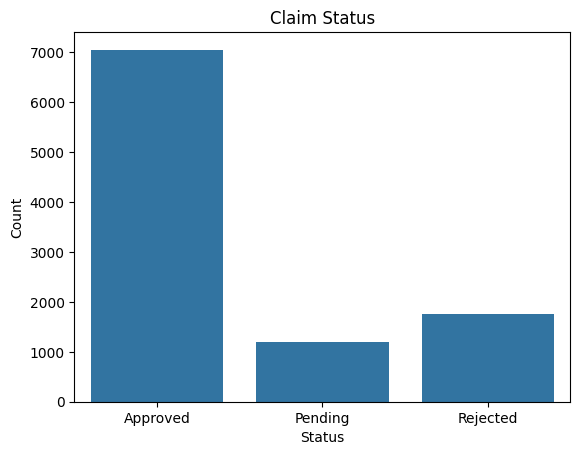

In [504]:
sns.countplot(df, x='Claim_Status')

plt.title("Claim Status")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

Untuk melakukan Machine Learning, akan di ambil data **'Approved'** dan **'Rejected'** sebagai data training

#### Handling Outlier

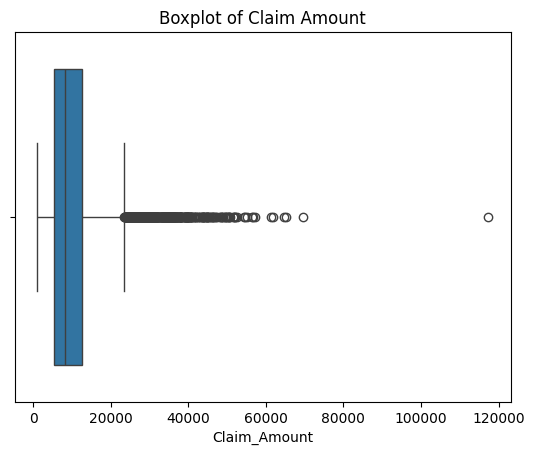

In [505]:
sns.boxplot(x=df["Claim_Amount"])

plt.title("Boxplot of Claim Amount")
plt.show()

In [506]:
df[df['Claim_Amount'] > 80000]

,Provider_ID,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,...,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Submission_mth,Claim_Submission_yr,Claim_DayOfWeek,Is_Weekend,Claim_Approval_Ratio,Claim_Amount_Diff
507,P0101,62,Female,117367.1856,76056.00912,Self-Pay,2022-01-04,0,94,General Practice,...,1,Inpatient,1,3.0,1,2022,1,0,0.648012,41311.17648


Tidak di drop karena merupakan informasi penting, yaitu kemungkinan salah satu bukti tanda Fraud.

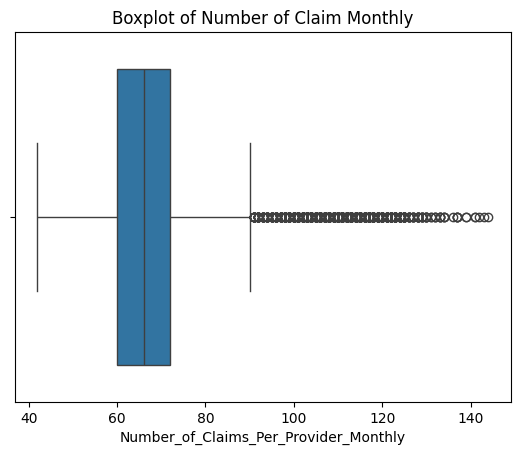

In [507]:
sns.boxplot(x=df["Number_of_Claims_Per_Provider_Monthly"])

plt.title("Boxplot of Number of Claim Monthly")
plt.show()

In [508]:
df[df['Number_of_Claims_Per_Provider_Monthly'] > 130]

,Provider_ID,Patient_Age,Patient_Gender,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,...,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Submission_mth,Claim_Submission_yr,Claim_DayOfWeek,Is_Weekend,Claim_Approval_Ratio,Claim_Amount_Diff
951,P0104,34,Male,11789.43024,7983.50448,Self-Pay,2024-09-15,1,133,General Practice,...,3,Outpatient,1,2.0,9,2024,6,1,0.677117,3805.92576
1232,P0110,36,Male,18390.67776,5895.87264,Self-Pay,2023-05-11,2,137,Orthopedics,...,0,Emergency,0,3.0,5,2023,3,0,0.320573,12494.80512
1316,P0291,41,Female,21240.84816,18797.41248,Self-Pay,2022-02-17,13,133,General Practice,...,3,Emergency,1,4.0,2,2022,3,0,0.884924,2443.43568
1450,P0131,63,Female,5581.38336,5504.09664,Private,2023-01-04,4,144,Pulmonology,...,0,Inpatient,1,NaN,1,2023,2,0,0.985976,77.28672
1529,P0206,65,Male,9662.97696,7857.78000,Medicare,2024-09-22,15,132,Internal Medicine,...,3,Outpatient,0,1.0,9,2024,6,1,0.813100,1805.19696
2968,P0223,22,Male,15287.09952,12929.32032,Medicare,2022-07-27,6,132,General Practice,...,0,Inpatient,0,3.0,7,2022,2,0,0.845711,2357.77920
4260,P0013,64,Female,4958.63760,3834.77472,Self-Pay,2021-02-24,29,132,Pulmonology,...,3,Emergency,1,4.0,2,2021,2,0,0.773197,1123.86288
4438,P0013,43,Male,6596.61744,2723.19936,Self-Pay,2022-07-02,4,137,Pulmonology,...,0,Inpatient,0,4.0,7,2022,5,1,0.412755,3873.41808
4714,P0282,34,Female,21055.28880,15805.31232,Private,2023-02-14,2,131,Pulmonology,...,3,Inpatient,1,4.0,2,2023,1,0,0.750622,5249.97648
4784,P0013,43,Male,12527.39376,10344.84528,Self-Pay,2021-12-02,8,134,Pulmonology,...,3,Inpatient,1,4.0,12,2021,3,0,0.825712,2182.54848


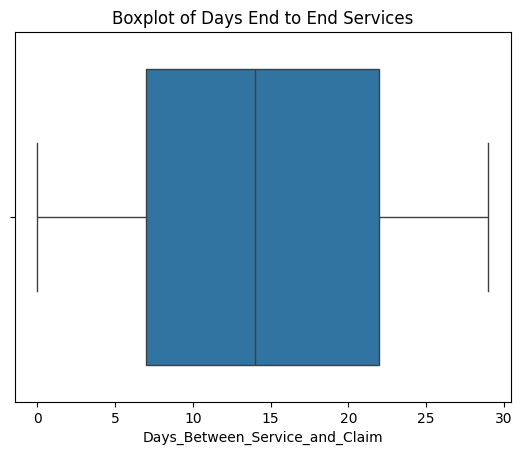

In [509]:
sns.boxplot(x=df["Days_Between_Service_and_Claim"])

plt.title("Boxplot of Days End to End Services")
plt.show()

In [510]:
# Winsorize kolom yang outlier-nya bukan signal fraud
for col in ['Claim_Amount', 'Approved_Amount', 'Prior_Visits_12m']:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower, upper)

In [511]:
df['Insurance_Type'].fillna(df['Insurance_Type'].mode()[0], inplace=True)
df['Provider_Specialty'].fillna(df['Provider_Specialty'].mode()[0], inplace=True)

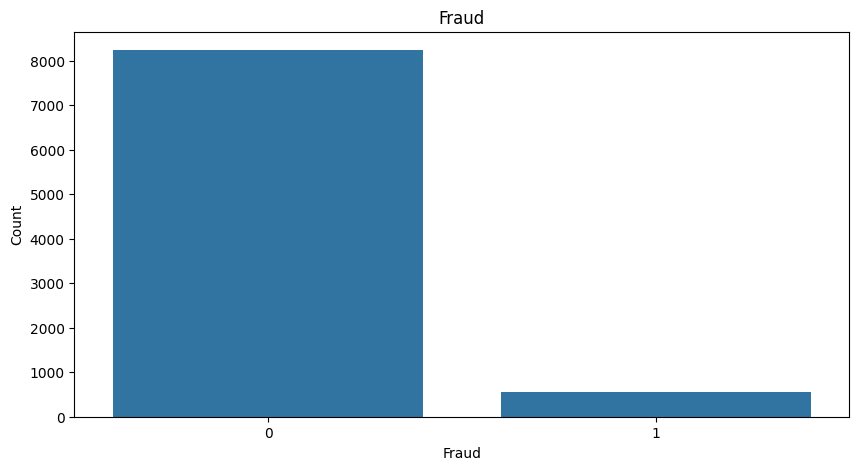

In [512]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.countplot(df[(df['Claim_Status'] == 'Approved') | (df['Claim_Status'] == 'Rejected')], x='Is_Fraud', ax=ax)

ax.set_facecolor((0, 0, 0, 0)) #Transparent Background
fig.patch.set_alpha(0.0)

plt.title("Fraud")
plt.xlabel("Fraud")
plt.ylabel("Count")
plt.show()

In [513]:
df.drop(['Is_Weekend', 'Claim_Submission_yr', 'Claim_Submission_mth', 
         'Claim_Submission_Date', 'Claim_Amount', 'Approved_Amount', 
         'Number_of_Claims_Per_Provider_Monthly', 'Claim_DayOfWeek',
         'Prior_Visits_12m', 'Provider_ID'], axis=1, inplace=True)

### Handling Imbalance Data

In [514]:
from imblearn.over_sampling import SMOTENC

TRAIN = df[(df['Claim_Status'] == 'Approved') | (df['Claim_Status'] == 'Rejected')].drop(['Claim_Status'], axis=1)
TEST = df[df['Claim_Status'] == 'Pending'].drop(['Claim_Status'], axis=1)

X_train = TRAIN.drop(['Is_Fraud'], axis=1)
X_test = TEST.drop(['Is_Fraud'], axis=1)

y_train = TRAIN['Is_Fraud']
y_test = TEST['Is_Fraud']

categorical_indices = [
    X_train.columns.get_loc(col)
    for col in X_train.select_dtypes('object').columns
]

smote_nc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=22
)

X_resampled, y_resampled = smote_nc.fit_resample(X_train, y_train)

In [515]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

scaler = StandardScaler().set_output(transform="pandas")
ohe = OneHotEncoder(sparse_output=False, drop='first')

X_resampled_num = scaler.fit_transform(X_resampled[X_resampled.select_dtypes(include="number").columns])
X_resampled_cat = ohe.fit_transform(X_resampled[X_resampled.select_dtypes(include="object").columns])
new_columns = ohe.get_feature_names_out()

X_test_num = scaler.transform(X_test[X_test.select_dtypes(include="number").columns])
X_test_cat = ohe.transform(X_test[X_test.select_dtypes(include="object").columns])

X_resampled = pd.concat([X_resampled_num.reset_index(drop=True), pd.DataFrame(X_resampled_cat, columns=new_columns)], axis=1)
X_test = pd.concat([X_test_num.reset_index(drop=True), pd.DataFrame(X_test_cat, columns=new_columns)], axis=1)

### Data Preparation & Train Data

In [516]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    random_state=22
)

xgb.fit(X_resampled, y_resampled)

y_pred = xgb.predict(X_test)

              precision    recall  f1-score   support

   Not Fraud       0.99      0.99      0.99       927
       Fraud       0.98      0.97      0.97       272

    accuracy                           0.99      1199
   macro avg       0.99      0.98      0.98      1199
weighted avg       0.99      0.99      0.99      1199

Recall Score:  0.9669117647058824


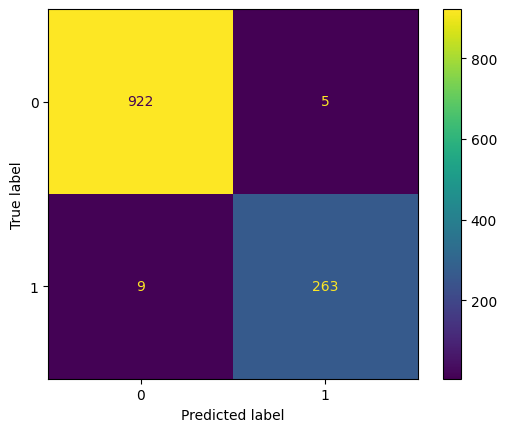

In [517]:
# Evaluate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, recall_score

target_names = ['Not Fraud', 'Fraud']
print(classification_report(y_test, y_pred, target_names=target_names))

print('Recall Score: ', recall_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=xgb.classes_)
disp.plot()
plt.show()

In [518]:
# Feature Importance

importance = xgb.feature_importances_

feature_names = X_resampled.columns

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
).reset_index(drop=True)

print(feature_importance.head(10))

                                feature  importance
0                  Claim_Approval_Ratio    0.695077
1        Days_Between_Service_and_Claim    0.161325
2                     Claim_Amount_Diff    0.028836
3                Chronic_Condition_Flag    0.027601
4  Provider_Specialty_Internal Medicine    0.018031
5                Insurance_Type_Private    0.013372
6                        Length_of_Stay    0.007389
7          Provider_Specialty_Neurology    0.006654
8   Provider_Specialty_General Practice    0.006357
9                 Visit_Type_Outpatient    0.005967


### **Deployment**

In [519]:
import joblib

joblib.dump(xgb, "fraud_pipeline.pkl")
print("✅ Model saved with joblib!")

✅ Model saved with joblib!


In [ ]:
!streamlit run app.py